In [1]:
#Import the required libraries for data handling, visualization, and machine learning.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files


In [3]:
print("Upload TRAIN CSV file:")
uploaded_train = files.upload()
train_data = pd.read_csv("train.csv")


Upload TRAIN CSV file:


Saving train.csv to train.csv


In [4]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
#Check for missing values and fill them using forward and backward filling.
# Data Preprocessing

# Checking for missing values
train_data.isnull().sum()

# Handling missing values: Let's use forward fill first, then backward fill for any remaining.

train_data.ffill(inplace=True)
train_data.bfill(inplace=True)

# Confirm if missing values are handled
train_data.isnull().sum()


,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [7]:
#Encode categorical variables and split the data into training and testing sets (80/20 split).
from sklearn.preprocessing import LabelEncoder

# Encoding categorical columns (e.g., 'Gender', 'Married', 'Education', etc.)
le = LabelEncoder()

# Example: Encoding a few columns (change as per your dataset's categorical columns)
train_data['Gender'] = le.fit_transform(train_data['Gender'])
train_data['Married'] = le.fit_transform(train_data['Married'])
train_data['Dependents'] = le.fit_transform(train_data['Dependents'])
train_data['Education'] = le.fit_transform(train_data['Education'])
train_data['Self_Employed'] = le.fit_transform(train_data['Self_Employed'])
train_data['Credit_History'] = le.fit_transform(train_data['Credit_History'])
train_data['Property_Area'] = le.fit_transform(train_data['Property_Area'])
train_data['Loan_Status'] = le.fit_transform(train_data['Loan_Status'])  # Target variable


# Define features (X) and target (y)
X = train_data.drop(['Loan_ID', 'Loan_Status'], axis=1) # Drop Loan_ID as it's an identifier and Loan_Status is the target
y = train_data['Loan_Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 491
Test set size: 123


In [8]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,1


In [10]:
#Initialize and train a standard Decision Tree Classifier.
# Training the Decision Tree Model

# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Drop 'Loan_ID' from X_train as it's a string identifier and not a feature for the model


dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [11]:
#Identify and display the most important features driving the predictions.
# Get feature importances from the trained model
feature_importances = dt_model.feature_importances_

# Create a pandas Series for easier inspection and sorting
feature_names = X_train.columns
importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance = importance_df.sort_values(ascending=False)

print("Feature Importances:")
print(sorted_importance)


Feature Importances:
ApplicantIncome      0.268292
Credit_History       0.256727
LoanAmount           0.185940
CoapplicantIncome    0.077997
Dependents           0.071118
Loan_Amount_Term     0.040578
Education            0.025167
Property_Area        0.024621
Married              0.023592
Self_Employed        0.023088
Gender               0.002880
dtype: float64


In [12]:
#Retrain a smaller model using only the top 3 features and a restricted depth for better interpretability.
# Let's select the top 3 most important features for a smaller tree
top_n_features = 3 # You can adjust this number
main_features = sorted_importance.head(top_n_features).index.tolist()

print(f"Selected main features: {main_features}")

# Create new training and testing sets with only the main features
X_train_main = X_train[main_features]
X_test_main = X_test[main_features]

# Train a new Decision Tree Classifier with only the main features
dt_model_small = DecisionTreeClassifier(random_state=42, max_depth=3) # Limiting depth for better visualization
dt_model_small.fit(X_train_main, y_train)


Selected main features: ['ApplicantIncome', 'Credit_History', 'LoanAmount']


DecisionTreeClassifier(max_depth=3, random_state=42)

In [13]:
#Evaluate the model's performance on the test set.
# Evaluation
y_pred = dt_model.predict(X_test) # Predict using the main_features test set

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy Score: {accuracy:.2%}")
#Multiplied by 100, rounded to 2 decimals, added %.
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Model Accuracy Score: 72.36%

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.56      0.59        43
           1       0.77      0.81      0.79        80

    accuracy                           0.72       123
   macro avg       0.69      0.69      0.69       123
weighted avg       0.72      0.72      0.72       123


Confusion Matrix:
 [[24 19]
 [15 65]]


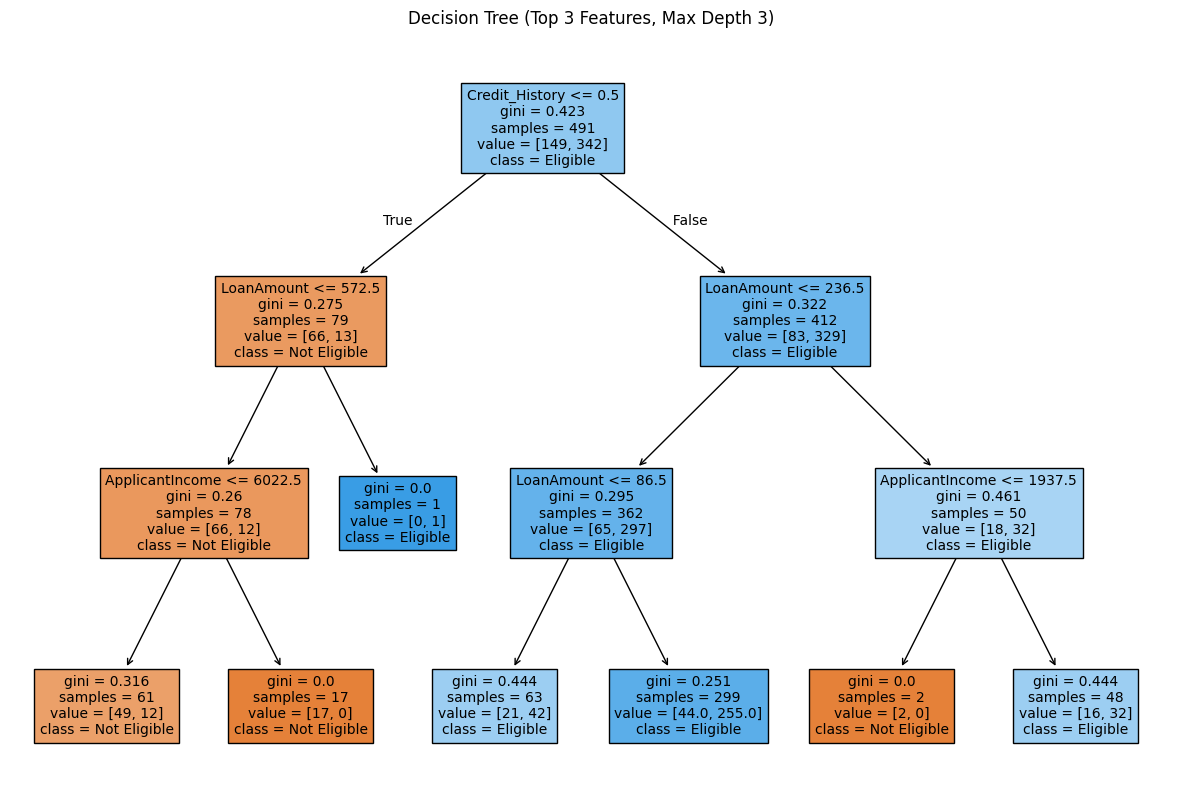

In [15]:
#Plot the graphical representation of the simplified decision tree.
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10)) # Adjust figure size for better readability of a smaller tree
plot_tree(
    dt_model_small,
    feature_names=main_features,
    class_names=["Not Eligible", "Eligible"],
    filled=True,
    fontsize=10 # Adjust font size if needed
)
plt.title(f"Decision Tree (Top {top_n_features} Features, Max Depth 3)")
plt.show()


In [17]:
#Output the decision logic in a human-readable text format.
from sklearn.tree import export_text

# Generate text representation of the smaller decision tree
tree_rules = export_text(dt_model_small, feature_names=main_features, class_names=["Not Eligible", "Eligible"])

print("Human-Readable Decision Tree Rules (Top Features, Max Depth 3):")
print(tree_rules)


Human-Readable Decision Tree Rules (Top Features, Max Depth 3):
|--- Credit_History <= 0.50
|   |--- LoanAmount <= 572.50
|   |   |--- ApplicantIncome <= 6022.50
|   |   |   |--- class: Not Eligible
|   |   |--- ApplicantIncome >  6022.50
|   |   |   |--- class: Not Eligible
|   |--- LoanAmount >  572.50
|   |   |--- class: Eligible
|--- Credit_History >  0.50
|   |--- LoanAmount <= 236.50
|   |   |--- LoanAmount <= 86.50
|   |   |   |--- class: Eligible
|   |   |--- LoanAmount >  86.50
|   |   |   |--- class: Eligible
|   |--- LoanAmount >  236.50
|   |   |--- ApplicantIncome <= 1937.50
|   |   |   |--- class: Not Eligible
|   |   |--- ApplicantIncome >  1937.50
|   |   |   |--- class: Eligible



In [18]:
#Provide a simple input prompt to test the model with new data.

# INTERACTIVE PREDICTION UI

print("\n=== Loan Eligibility Predictor ===")
print("Enter new applicant details below:")

# Ask user for input
# Make sure to match feature names from your dataset
# Example assumes the features are: 'ApplicantIncome', 'LoanAmount', 'Credit_History'
# You can add more features if your dataset has them

applicant_income = float(input("Applicant Income: "))
loan_amount = float(input("Loan Amount: "))
credit_history = int(input("Credit History (0=No, 1=Yes): "))

# Create a DataFrame for the new applicant, ensuring column order matches main_features
new_applicant = pd.DataFrame([[applicant_income, credit_history, loan_amount]],
                             columns=['ApplicantIncome', 'Credit_History', 'LoanAmount'])

# Align new applicant columns with training dataset (this line is removed as dt_model_small expects only main_features)
# new_applicant = new_applicant.reindex(columns=X_train.columns, fill_value=0)

# Make prediction
prediction = dt_model_small.predict(new_applicant) # Changed 'model' to 'dt_model_small'

# Display result
print("\n=== Prediction Result ===")
if prediction[0] == 1:
    print("Loan Eligible ✅   ")
else:
    print("Loan Not Eligible ❌  ")




=== Loan Eligibility Predictor ===
Enter new applicant details below:
Applicant Income: 4000
Loan Amount: 400
Credit History (0=No, 1=Yes): 1

=== Prediction Result ===
Loan Eligible ✅   
